# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [44]:
!pip install pybalmorel

In [45]:
import pybalmorel 
import matplotlib.pyplot as plt

In [46]:
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

# Write the exact names of the scenarios and the path (or paths) that they aC:\\Users\\Bruger\\OneDrive\\Documents\\Master\\4. June 2026\\Large scale energy system analysis\\Excersice\\Lecture_2\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\Lecture_2_Ex_0\\model\\re in
res = MainResults(files=["1.gdx", "2.gdx", "3.gdx", "4.gdx", "Base.gdx", "2025.gdx"
                                                  ], 
                  paths='C:\\Users\\inesm\\Documents\\GAMS\\BalmorelSimpleModel_LP\\BalmorelSimpleModel_LP\\Balmorel\\LSESAub\\0_results_for_python_noDECOM')

Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\1.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\2.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\3.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\4.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\Base.gdx
Loading C:\Users\inesm\Documents\GAMS\BalmorelSimpleModel_LP\BalmorelSimpleModel_LP\Balmorel\LSESAub\0_results_for_python_noDECOM\2025.gdx


c:\Users\inesm\anaconda3\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (53.5.1) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


## Plotting CO2 emissions Validation

Raw result columns: ['Scenario', 'Y', 'C', 'RRR', 'AAA', 'G', 'FFF', 'TECH_TYPE', 'UNITS', 'Value']
Unique values in C: ['DENMARK', 'NORWAY']
Pivot columns after aggregation (kton): ['DENMARK', 'NORWAY']
C          DENMARK    NORWAY
Scenario                    
1         3.151366  0.000612
2         3.222512  0.000436
2025      5.126638  0.000964
3         3.573816  0.000460
4         3.546214  0.000460


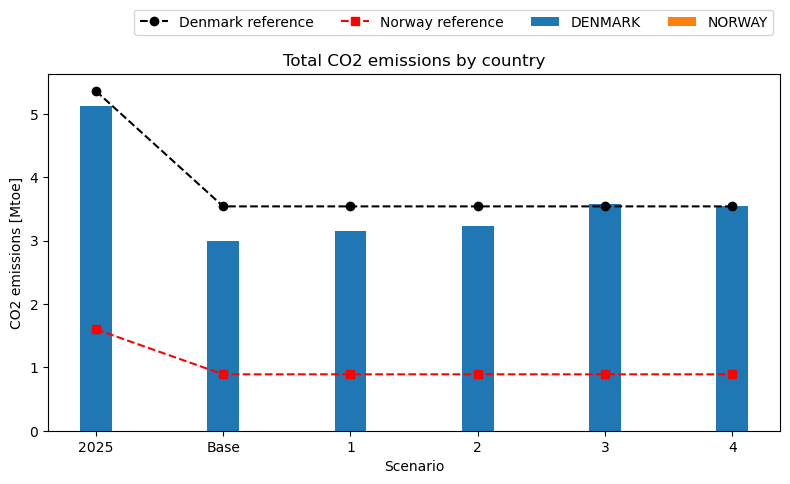

In [47]:
import pandas as pd
import numpy as np

obj_emi = res.get_result('EMI_YCRAG')

# Print raw columns and values to verify that Norway is present
print('Raw result columns:', obj_emi.columns.tolist())
print('Unique values in C:', sorted(obj_emi['C'].dropna().unique().tolist()))

# Aggregate by scenario and region/country label in C (values are in kton)
obj_emi = obj_emi.pivot_table(
    index='Scenario',
    columns='C',
    values='Value',
    aggfunc='sum',
    fill_value=0
)

# Convert from kton -> Mt (1 kton = 0.001 Mt)
obj_emi_mton = obj_emi / 1000.0
print('Pivot columns after aggregation (kton):', obj_emi.columns.tolist())
print(obj_emi_mton.head())

# Reorder scenarios and ensure no missing values
obj_emi_mton = obj_emi_mton.reindex(['2025', 'Base', '1', '2', '3', '4']).fillna(0)

# Hardcoded reference values (in Mt) for comparison
# Replace these numbers if your references are in other units
denmark_ref = {'2025': 5.36, 'Base': 3.54, '1': 3.54, '2': 3.54, '3': 3.54, '4': 3.54}  # Denmark: 2025 and 2030(Base)
norway_ref = {'2025': 1.60, 'Base': 0.89, '1': 0.89, '2': 0.89, '3': 0.89, '4': 0.89}   # Norway: 2025 and 2030(Base)

# Build series aligned with the DataFrame index
den_series = pd.Series(denmark_ref).reindex(obj_emi_mton.index)
nor_series = pd.Series(norway_ref).reindex(obj_emi_mton.index)

# Plot stacked bars (Mt) with thinner columns
ax = obj_emi_mton.plot(kind='bar', stacked=True, ylabel='CO2 emissions [Mtoe]', grid=False, rot=0, figsize=(8,5), width=0.25)
ax.set_title('Total CO2 emissions by country')

# Overlay hardcoded reference points/lines
x = np.arange(len(obj_emi_mton.index))
ax.plot(x, den_series.values, marker='o', linestyle='--', color='black', label='Denmark reference')
ax.plot(x, nor_series.values, marker='s', linestyle='--', color='red', label='Norway reference')

# Adjust legend and layout
ax.legend(bbox_to_anchor=(1, 1.2), ncols=4)
plt.tight_layout()
plt.show()


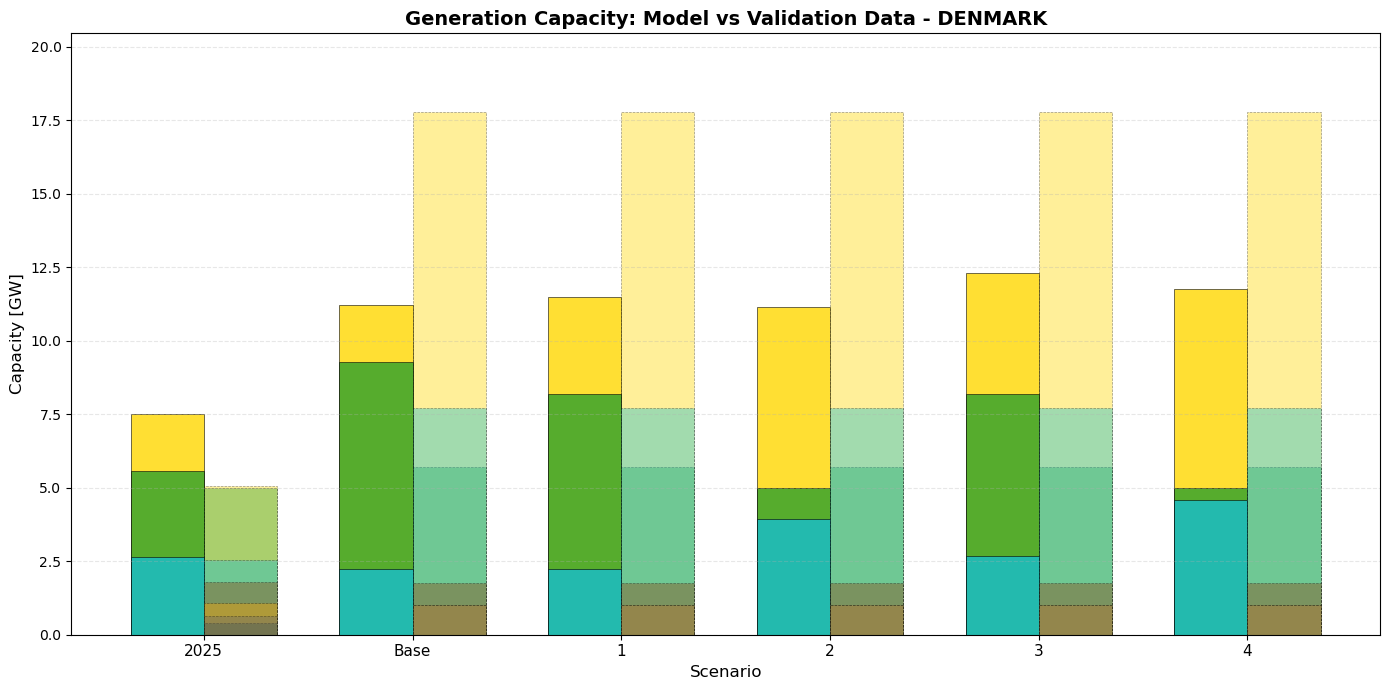

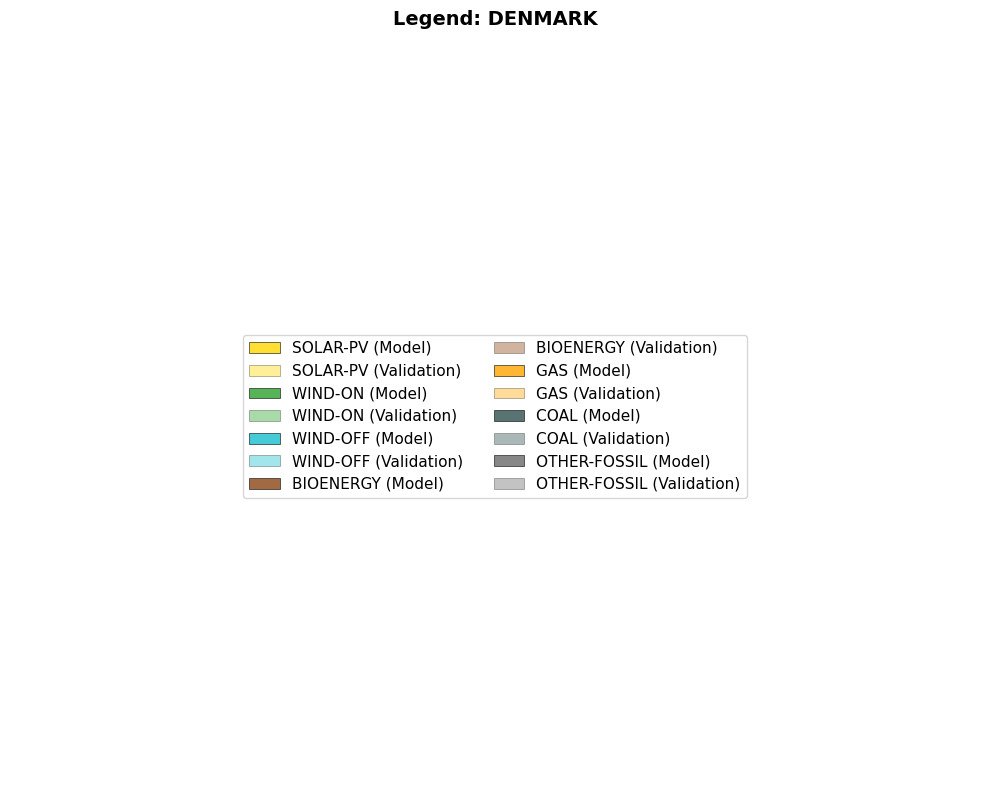

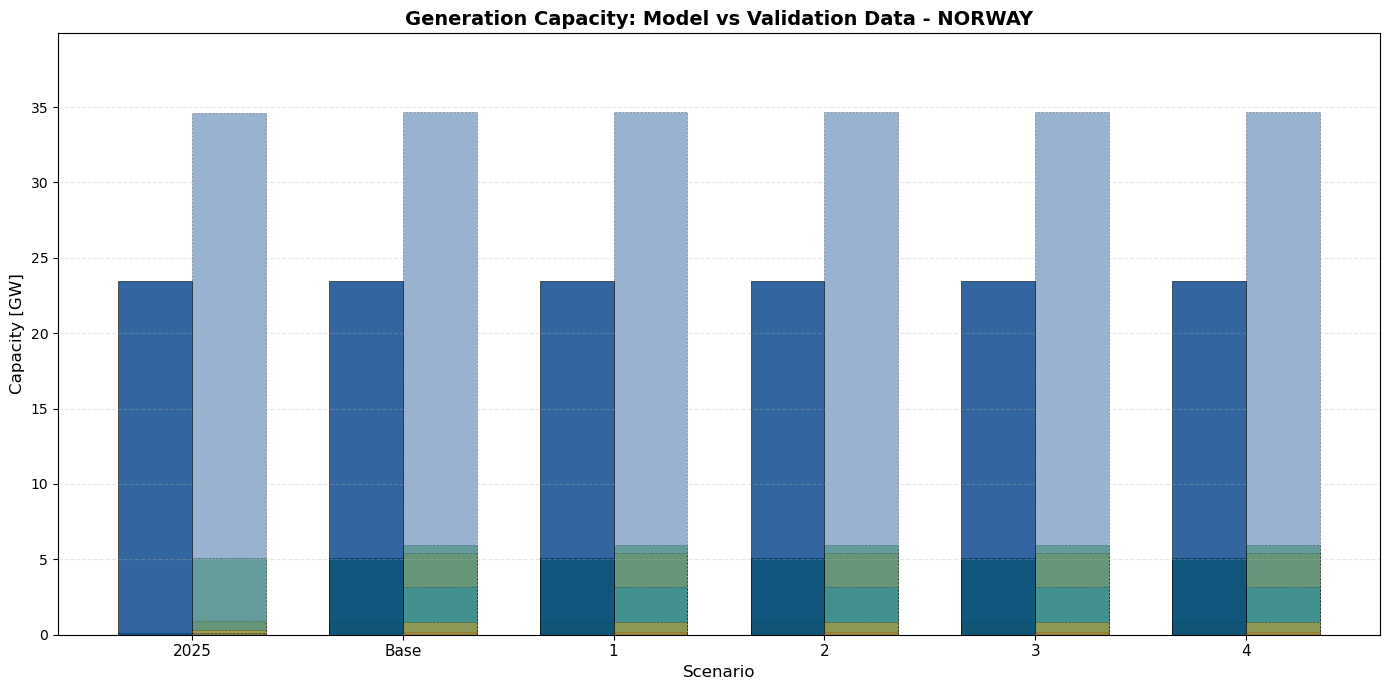

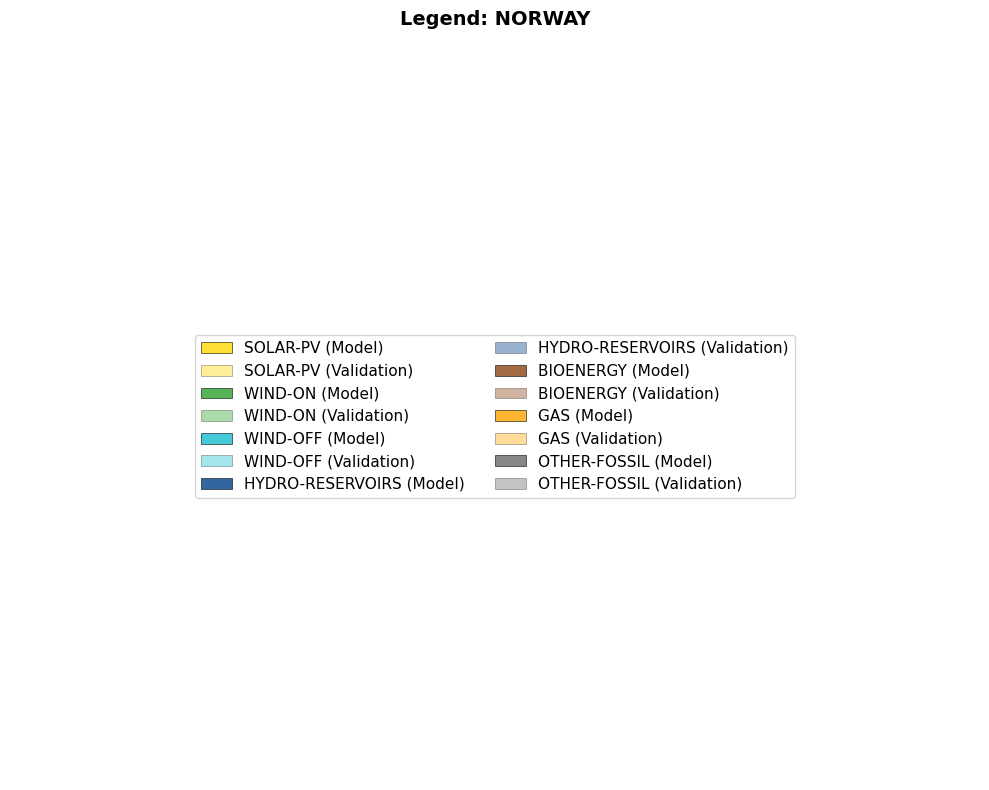


===== HARDCODED VALIDATION DATA =====

DENMARK - 2025:
  SOLAR-PV: 5.05 GW
  WIND-ON: 5.0 GW
  WIND-OFF: 2.55 GW
  BIOENERGY: 1.79 GW
  GAS: 1.08 GW
  COAL: 0.41 GW
  OTHER-FOSSIL: 0.65 GW

DENMARK - 2030:
  SOLAR-PV: 17.79 GW
  WIND-ON: 5.7 GW
  WIND-OFF: 7.71 GW
  BIOENERGY: 1.77 GW
  GAS: 1.0 GW
  OTHER-FOSSIL: 1.0 GW

NORWAY - 2025:
  SOLAR-PV: 0.9 GW
  WIND-ON: 5.08 GW
  WIND-OFF: 0.101 GW
  HYDRO-RESERVOIRS: 34.6 GW
  GAS: 0.34 GW
  OTHER-FOSSIL: 0.14 GW

NORWAY - 2030:
  SOLAR-PV: 5.39 GW
  WIND-ON: 5.98 GW
  WIND-OFF: 3.19 GW
  HYDRO-RESERVOIRS: 34.69 GW
  BIOENERGY: 0.19 GW
  GAS: 0.83 GW


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# HARDCODED VALIDATION DATA FROM TABLE
# ============================================================
validation_data = {
    ('DENMARK', '2025'): {
        'SOLAR-PV': 5.05, 'WIND-ON': 5.0, 'WIND-OFF': 2.55, 'HYDRO-RESERVOIRS': 0,
        'BIOENERGY': 1.79, 'NUCLEAR': 0, 'GAS': 1.08, 'COAL': 0.41, 'OTHER-FOSSIL': 0.65
    },
    ('DENMARK', '2030'): {
        'SOLAR-PV': 17.79, 'WIND-ON': 5.7, 'WIND-OFF': 7.71, 'HYDRO-RESERVOIRS': 0,
        'BIOENERGY': 1.77, 'NUCLEAR': 0, 'GAS': 1.0, 'COAL': 0, 'OTHER-FOSSIL': 1.0
    },
    ('NORWAY', '2025'): {
        'SOLAR-PV': 0.9, 'WIND-ON': 5.08, 'WIND-OFF': 0.101, 'HYDRO-RESERVOIRS': 34.6,
        'BIOENERGY': 0, 'NUCLEAR': 0, 'GAS': 0.34, 'COAL': 0, 'OTHER-FOSSIL': 0.14
    },
    ('NORWAY', '2030'): {
        'SOLAR-PV': 5.39, 'WIND-ON': 5.98, 'WIND-OFF': 3.19, 'HYDRO-RESERVOIRS': 34.69,
        'BIOENERGY': 0.19, 'NUCLEAR': 0, 'GAS': 0.83, 'COAL': 0, 'OTHER-FOSSIL': 0
    }
}

# Retrieve installed capacity results from model
obj = res.get_result('G_CAP_YCRAF')

# Define scenario order
scenario_order = ['2025', 'Base', '1', '2', '3', '4']

# Countries to analyse
countries = ['DENMARK', 'NORWAY']

# Keep only Denmark and Norway
obj = obj[obj['Country'].isin(countries)].copy()

# Prepare model data - aggregate all technologies
def prepare_model_data(data, country, scenario_order_list):
    df = data[data['Country'] == country].copy()
    df = df.pivot_table(
        index='Scenario',
        columns='Technology',
        values='Value',
        aggfunc='sum'
    )
    df = df.reindex(scenario_order_list).fillna(0)
    return df

model_data = {}
for country in countries:
    model_data[country] = prepare_model_data(obj, country, scenario_order)

# Validation technologies to plot (matching the table columns)
validation_techs = ['SOLAR-PV', 'WIND-ON', 'WIND-OFF', 'HYDRO-RESERVOIRS', 'BIOENERGY', 'GAS', 'COAL', 'OTHER-FOSSIL', 'NUCLEAR']

# Fixed color for each technology
technology_colors = {
    'SOLAR-PV': '#FFD700',
    'WIND-ON': '#2CA02C',
    'WIND-OFF': '#17BECF',
    'HYDRO-RESERVOIRS': '#003F88',
    'BIOENERGY': '#8B4513',
    'NUCLEAR': '#FF69B4',
    'GAS': '#FFA500',
    'COAL': '#2F4F4F',
    'OTHER-FOSSIL': '#696969',
}

def create_legend_for_country(country, scenario_list, validation_techs, technology_colors, validation_data, model_data):
    """Create a separate legend figure for a specific country"""
    
    # Identify which technologies have data
    techs_with_data = []
    for tech in validation_techs:
        has_model_data = False
        has_val_data = False
        
        # Check if tech has model data
        if tech in model_data[country].columns:
            if model_data[country][tech].sum() > 0:
                has_model_data = True
        
        # Check if tech has validation data
        for scenario in scenario_list:
            if scenario == '2025':
                val_key = (country, '2025')
            else:
                val_key = (country, '2030')
            
            if val_key in validation_data:
                if validation_data[val_key].get(tech, 0) > 0:
                    has_val_data = True
        
        if has_model_data or has_val_data:
            techs_with_data.append(tech)
    
    # Create legend figure
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.axis('off')
    
    legend_elements = []
    for tech in techs_with_data:
        color = technology_colors.get(tech, '#CCCCCC')
        # Model bar
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.8, 
                                            edgecolor='black', linewidth=0.5, label=f'{tech} (Model)'))
        # Validation bar
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.4, 
                                            edgecolor='black', linewidth=0.5, label=f'{tech} (Validation)'))
    
    ax.legend(handles=legend_elements, loc='center', fontsize=11, ncol=2, frameon=True)
    plt.title(f'Legend: {country}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

def plot_model_vs_validation(country, scenario_list):
    """Plot model vs validation data as side-by-side bars for each scenario (no legend)"""
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x_pos = np.arange(len(scenario_list))
    bar_width = 0.35
    
    # Calculate y-axis max based on data
    ymax = 0
    for scenario in scenario_list:
        for tech in validation_techs:
            if tech in model_data[country].columns:
                ymax = max(ymax, model_data[country].loc[scenario, tech])
            
            if scenario == '2025':
                val_key = (country, '2025')
            else:
                val_key = (country, '2030')
            
            if val_key in validation_data:
                ymax = max(ymax, validation_data[val_key].get(tech, 0))
    
    # Add 10% margin to y-axis
    ymax = ymax * 1.15
    
    # Process each technology
    for tech_idx, tech in enumerate(validation_techs):
        model_vals = []
        val_vals = []
        
        for scenario in scenario_list:
            # Model value
            if tech in model_data[country].columns:
                model_vals.append(model_data[country].loc[scenario, tech])
            else:
                model_vals.append(0)
            
            # Validation value (only for 2025 and Base/2030)
            if scenario == '2025':
                val_key = (country, '2025')
            else:  # Base represents 2030
                val_key = (country, '2030')
            
            if val_key in validation_data:
                val_vals.append(validation_data[val_key].get(tech, 0))
            else:
                val_vals.append(0)
        
        # Plot side-by-side bars for this technology
        model_vals = np.array(model_vals)
        val_vals = np.array(val_vals)
        
        # Only plot if there is data
        if model_vals.sum() > 0 or val_vals.sum() > 0:
            color = technology_colors.get(tech, '#CCCCCC')
            
            # Model bars (left)
            ax.bar(x_pos - bar_width/2, model_vals, bar_width, 
                   color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
            
            # Validation bars (right)
            ax.bar(x_pos + bar_width/2, val_vals, bar_width,
                   color=color, alpha=0.4, edgecolor='black', linewidth=0.5, linestyle='--')
    
    ax.set_xlabel('Scenario', fontsize=12)
    ax.set_ylabel('Capacity [GW]', fontsize=12)
    ax.set_title(f'Generation Capacity: Model vs Validation Data - {country}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(scenario_list, fontsize=11)
    ax.set_ylim(0, ymax)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Plot for each country - plot first, then legend
for country in countries:
    plot_model_vs_validation(country, scenario_order)
    create_legend_for_country(country, scenario_order, validation_techs, technology_colors, validation_data, model_data)
    
# Print validation data for verification
print('\n===== HARDCODED VALIDATION DATA =====')
for key, values in validation_data.items():
    country, year = key
    print(f'\n{country} - {year}:')
    for tech, val in values.items():
        if val > 0:
            print(f'  {tech}: {val} GW')
